In [7]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [8]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("naturalNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)
    
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)

huresids = protein[1][0].select_atoms("protein").residues.resids    
    
alignedprotein=[]
alignedproteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and resid 0:1000"))
        sub2.append("protein and resid 0:1000")
        
    alignedprotein.append(sub)
    alignedproteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [9]:
allhbondarrays = []
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        
        sub.append(load(("raw_hbonds_cutoff3d5_"+str(i)+"_"+str(j)+"joblib.npy")))
    allhbondarrays.append(sub)

In [10]:
hbondDFs=[]
for i in range(len(allhbondarrays)):
    sub=[]
    for j in range(len(allhbondarrays[i])):
        tdf=pd.DataFrame(allhbondarrays[i][j],columns=["frame","donorid","hid","acceptorid","distance","angle"])
        tu = systems[i][j]

        atomid_to_resid=dict(zip(tu.atoms.ids,tu.atoms.resids))


        tdf["donor_resid"] = tdf["donorid"].map(atomid_to_resid)
        tdf["acceptor_resid"] = tdf["acceptorid"].map(atomid_to_resid)

        resid_to_resname=dict(zip(tu.residues.resids,tu.residues.resnames))

        tdf["donor_resname"] = tdf["donor_resid"].map(resid_to_resname)
        tdf["acceptor_resname"] = tdf["acceptor_resid"].map(resid_to_resname)
        
        # Omit non-protein hbonds for now
        tdf = tdf[(tdf["donor_resid"] <inf) & (tdf["acceptor_resid"] < inf)]        
        sub.append(tdf)
    hbondDFs.append(sub)

In [12]:
hbondDFs[0][0]

,frame,donorid,hid,acceptorid,distance,angle,donor_resid,acceptor_resid,donor_resname,acceptor_resname
4,0.0,50.0,51.0,8.0,3.127490,162.121964,293.0,290.0,ASP,GLU
6,0.0,64.0,65.0,15.0,3.496566,166.401146,294.0,290.0,ALA,GLU
7,0.0,86.0,87.0,49.0,2.806888,163.839999,295.0,293.0,ARG,ASP
8,0.0,99.0,100.0,1186.0,3.140763,165.811422,296.0,365.0,ARG,VAL
12,0.0,129.0,130.0,72.0,2.816756,172.164338,297.0,295.0,TYR,ARG
...,...,...,...,...,...,...,...,...,...,...
1761413,4000.0,2950.0,2951.0,1377.0,2.755322,154.539458,478.0,377.0,TYR,VAL
1761415,4000.0,2990.0,2991.0,1351.0,2.865680,156.756585,481.0,375.0,PRO,LEU
1761424,4000.0,3119.0,3120.0,515.0,2.976757,169.853498,488.0,322.0,MET,SER
1761426,4000.0,3150.0,3151.0,482.0,2.711604,164.085120,490.0,319.0,LEU,GLN


In [19]:

all_important_2d_hb_propensities_symmetric=[]
for i in range(1,len(systems)):
    sub2=[]
    for j in range(len(systems[i])):
        
        #select the current systems hbond df
        tdf = hbondDFs[i][j]
        #remove equilibration period
        eqtdf = tdf[tdf["frame"]>EQPOINT]
   
        symmetric_2d_hbonds = zeros((len(huresids),len(huresids)))
        for en in range(len(eqtdf)):
            dr = int(eqtdf["donor_resid"].iloc[en])
            ar = int(eqtdf["acceptor_resid"].iloc[en])
            symmetric_2d_hbonds[dr-290,ar-290]+=1
            symmetric_2d_hbonds[ar-290,dr-290]+=1
        symmetric_2d_hbonds_avg = symmetric_2d_hbonds/((max(eqtdf.frame)-EQPOINT))
            
            



        sub2.append(symmetric_2d_hbonds_avg)
    all_important_2d_hb_propensities_symmetric.append(sub2)


In [28]:
# take averages
system_avg_important_2d_hb_propensities=[]
system_sem_important_2d_hb_propensities=[]
for i in range(len(all_important_2d_hb_propensities_symmetric)):
    system_avg_important_2d_hb_propensities.append(mean(all_important_2d_hb_propensities_symmetric[i],axis = 0))
    system_sem_important_2d_hb_propensities.append(scipy.stats.sem(all_important_2d_hb_propensities_symmetric[i],axis =0))

    
diffmap = system_avg_important_2d_hb_propensities[1]-system_avg_important_2d_hb_propensities[0]
diffsem = sqrt(system_sem_important_2d_hb_propensities[1]**2 + system_sem_important_2d_hb_propensities[0]**2)

importantIndices = array(huresids)-290

importantMap = zeros((len(huresids),len(huresids)))
importantSem = zeros((len(huresids),len(huresids)))
for i in range(len(importantMap)):
    for j in range(len(importantMap[i])):
        importantMap[i][j] = diffmap[importantIndices[i],importantIndices[j]]
        importantSem[i][j] = diffsem[importantIndices[i],importantIndices[j]]

#save("importantHBMap.npy",importantMap.T)
#save("importantHBSem.npy",importantSem.T)

Text(0.5, 1.0, 'hbonds diff map')

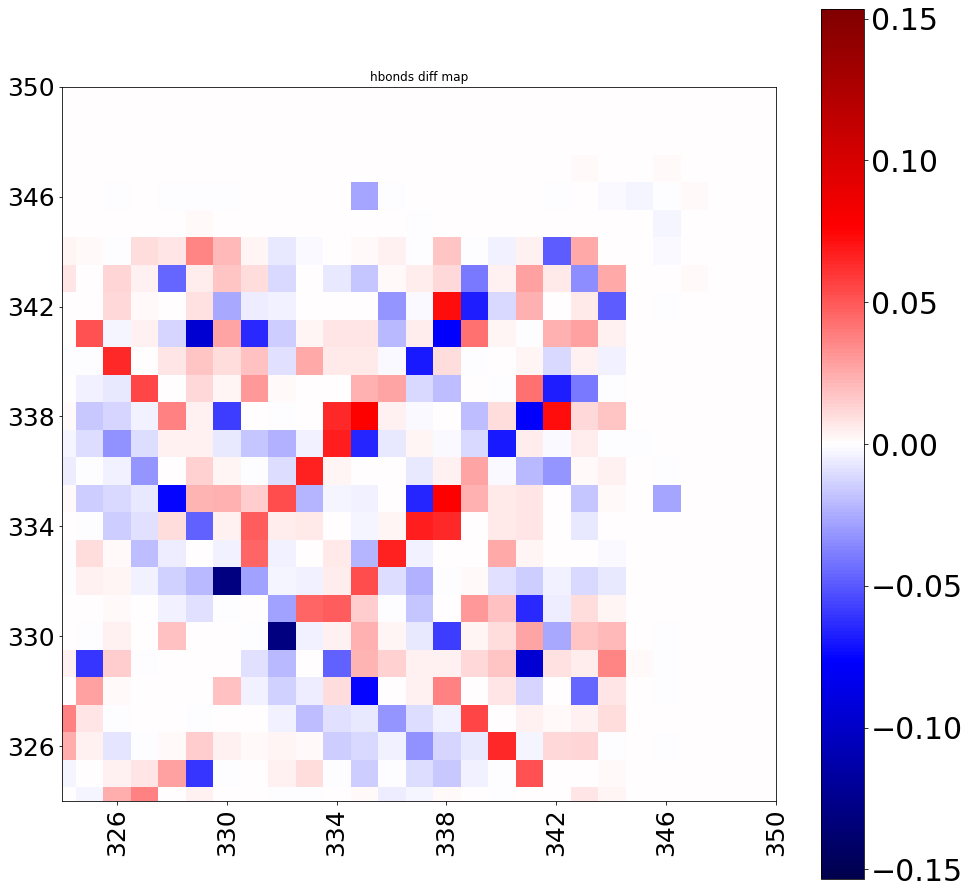

In [48]:
dr = max(abs(importantMap.flatten()))


figure(figsize = (16,16))
imshow(importantMap.T,origin = "lower",cmap = "seismic",vmax = dr,vmin = -dr)
asdf=xticks(arange(len(huresids))[::4],huresids[::4],fontsize = 25,rotation = 90)
asdf=yticks(arange(len(huresids))[::4],huresids[::4],fontsize = 25)
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 

xlim(324-290,350-290)
ylim(324-290,350-290)
title("hbonds diff map")

(34.0, 60.0)

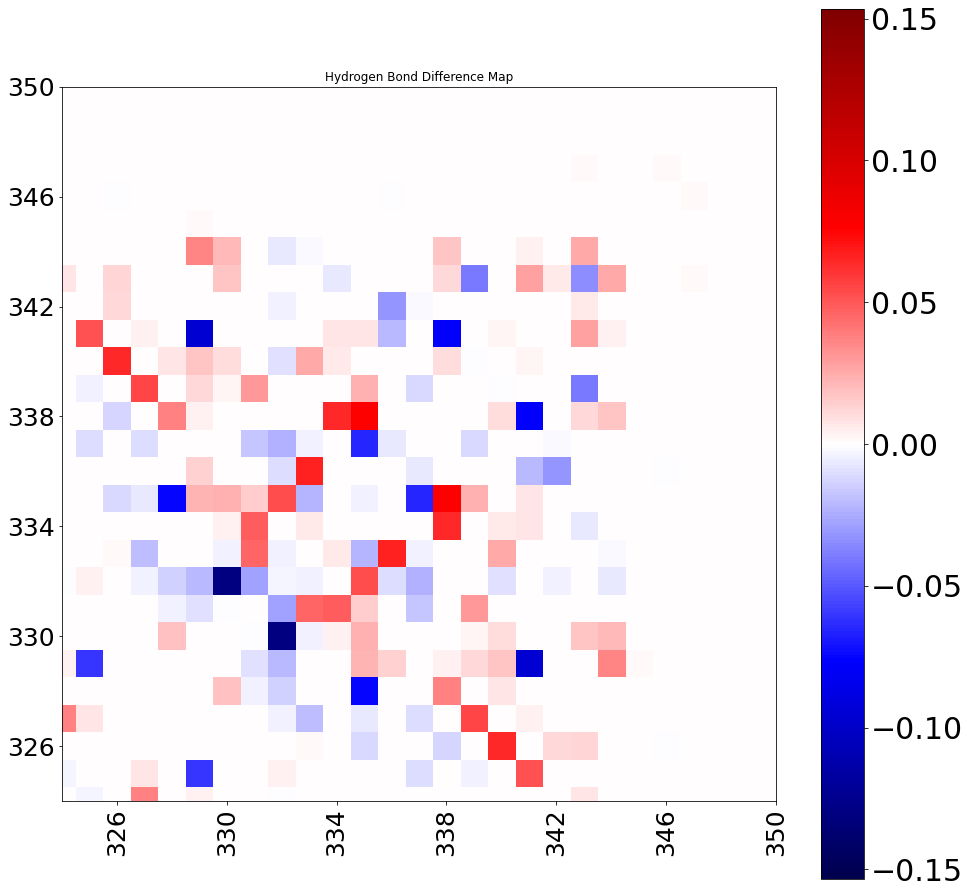

In [50]:
diffmap = system_avg_important_2d_hb_propensities[1]-system_avg_important_2d_hb_propensities[0]
diffsem = sqrt(system_sem_important_2d_hb_propensities[1]**2 + system_sem_important_2d_hb_propensities[0]**2)

signif_important_map = copy(diffmap)
for i in range(len(signif_important_map)):
    for j in range(len(signif_important_map)):
        if abs(diffsem[i][j]) > abs(signif_important_map[i][j]):
            signif_important_map[i][j] = 0
            
dr = max(abs(signif_important_map.flatten()))

figure(figsize = (16,16))
imshow(signif_important_map.T,origin = "lower",cmap = "seismic",vmax = dr,vmin= -dr)
asdf=xticks(arange(len(huresids))[::4],huresids[::4],fontsize = 25,rotation = 90)
asdf=yticks(arange(len(huresids))[::4],huresids[::4],fontsize = 25)
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 

title('Hydrogen Bond Difference Map')


xlim(324-290,350-290)
ylim(324-290,350-290)